In [147]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import math

In [148]:
def create_random_cube():
    center = np.random.uniform(-5, 5, size=(3,))
    size = np.random.uniform(1, 3)
    base_vertices = np.array([
        [-1, -1, -1], [1, -1, -1], [1, 1, -1], [-1, 1, -1],
        [-1, -1, 1], [1, -1, 1], [1, 1, 1], [-1, 1, 1]
    ]) * size / 2
    return base_vertices + center

In [149]:
def add_line_if_given(func):
    def wrapper(*args, line_data=None, plane_data=None, projected_vertices=None, **kwargs):
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        kwargs["ax"] = ax

        if projected_vertices is not None:
            kwargs["projected_vertices"] = projected_vertices

        func(*args, **kwargs)

        if line_data is not None:
            point, direction = line_data
            t = np.linspace(-5, 5, 100)
            line_pts = point[:, np.newaxis] + np.outer(direction, t)
            ax.plot(line_pts[0], line_pts[1], line_pts[2], color='purple', label='Line')

        if plane_data is not None:
            point, normal = plane_data
            d1 = np.cross(normal, [0, 0, 1])
            if np.linalg.norm(d1) < 1e-6:
                d1 = np.cross(normal, [0, 1, 0])
            d1 /= np.linalg.norm(d1)
            d2 = np.cross(normal, d1)

            grid_size = 5
            s = np.linspace(-grid_size, grid_size, 10)
            xx, yy = np.meshgrid(s, s)
            plane_points = point[:, np.newaxis, np.newaxis] + d1[:, np.newaxis, np.newaxis] * xx + d2[:, np.newaxis, np.newaxis] * yy
            X, Y, Z = plane_points[0], plane_points[1], plane_points[2]
            ax.plot_surface(X, Y, Z, alpha=0.3, color='cyan')

        ax.legend()
        plt.show()
    return wrapper

@add_line_if_given
def plot_cubes(original_vertices, transformed_vertices=None, colors=["blue", "red"], space_limits=10, ax=None, projected_vertices=None):
    def plot_cube(vertices, color):
        edges = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],
            [vertices[4], vertices[5], vertices[6], vertices[7]],
            [vertices[0], vertices[1], vertices[5], vertices[4]],
            [vertices[2], vertices[3], vertices[7], vertices[6]],
            [vertices[1], vertices[2], vertices[6], vertices[5]],
            [vertices[4], vertices[7], vertices[3], vertices[0]]
        ]
        ax.add_collection3d(Poly3DCollection(edges, alpha=0.5, edgecolor='k', facecolor=color))

    plot_cube(original_vertices, colors[0])

    if transformed_vertices is not None:
        plot_cube(transformed_vertices, colors[1])

    if projected_vertices is not None:
        plot_cube(projected_vertices, "green")

    ax.set_xlim([-space_limits, space_limits])
    ax.set_ylim([-space_limits, space_limits])
    ax.set_zlim([-space_limits, space_limits])

    ax.plot([-space_limits, space_limits], [0, 0], [0, 0], color='red', label='X')
    ax.plot([0, 0], [-space_limits, space_limits], [0, 0], color='green', label='Y')
    ax.plot([0, 0], [0, 0], [-space_limits, space_limits], color='blue', label='Z')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')


### Scaling the Cube

In [206]:
def scale_cube(vertices, scale_factor):
    vertices_homogeneous = np.column_stack((vertices, np.ones(vertices.shape[0])))

    center = np.mean(vertices, axis=0)

    T = np.array([[1, 0, 0, -center[0]],
                  [0, 1, 0, -center[1]],
                  [0, 0, 1, -center[2]],
                  [0, 0, 0, 1]])

    S = np.array([[scale_factor, 0, 0, 0],
                  [0, scale_factor, 0, 0],
                  [0, 0, scale_factor, 0],
                  [0, 0, 0, 1]])

    T_inv = np.array([[1, 0, 0, center[0]],
                      [0, 1, 0, center[1]],
                      [0, 0, 1, center[2]],
                      [0, 0, 0, 1]])

    scaled_vertices_homogeneous = vertices_homogeneous @ T.T @ S.T @ T_inv.T

    return scaled_vertices_homogeneous[:, :3]


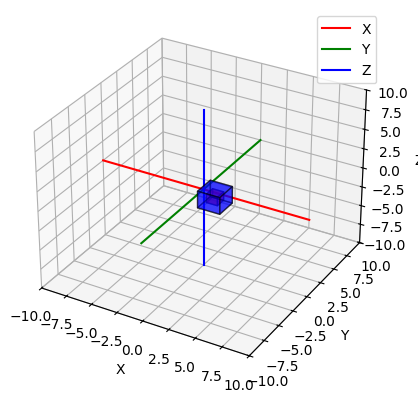

In [209]:
cube_vertices = create_random_cube()

scale_factor = 0.5
scaled_vertices = scale_cube(cube_vertices, scale_factor)

plot_cubes(cube_vertices, scaled_vertices)

### Reflecting the Cube

In [152]:
def reflect_cube(vertices):
    vertices_homogeneous = np.column_stack((vertices, np.ones(vertices.shape[0])))
    reflection_matrix = np.array([[-1, 0, 0, 0],
                                  [0, -1, 0, 0],
                                  [0, 0, -1, 0],
                                  [0, 0, 0, 1]])
    reflected_vertices_homogeneous = vertices_homogeneous @ reflection_matrix.T
    return reflected_vertices_homogeneous[:, :3]

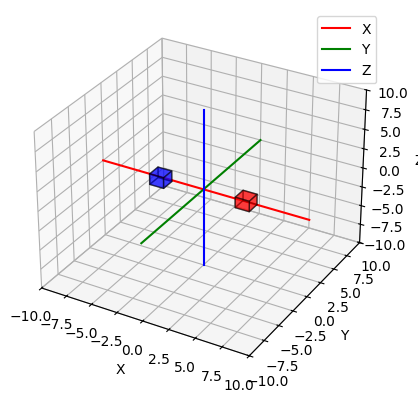

In [153]:
reflected_vertices = reflect_cube(scaled_vertices)

plot_cubes(scaled_vertices, reflected_vertices)

In [154]:
def reflect_cube_plane(vertices, plane="XY"):
    vertices_homogeneous = np.column_stack((vertices, np.ones(vertices.shape[0])))

    if plane == "XY":
        reflection_matrix = np.array([[1, 0, 0, 0],
                                      [0, 1, 0, 0],
                                      [0, 0, -1, 0],
                                      [0, 0, 0, 1]])
    elif plane == "XZ":
        reflection_matrix = np.array([[1, 0, 0, 0],
                                      [0, -1, 0, 0],
                                      [0, 0, 1, 0],
                                      [0, 0, 0, 1]])
    elif plane == "YZ":
        reflection_matrix = np.array([[-1, 0, 0, 0],
                                      [0, 1, 0, 0],
                                      [0, 0, 1, 0],
                                      [0, 0, 0, 1]])
    else:
        raise ValueError("Invalid plane. Choose from 'XY', 'XZ', or 'YZ'.")

    reflected_vertices_homogeneous = vertices_homogeneous @ reflection_matrix.T
    return reflected_vertices_homogeneous[:, :3]


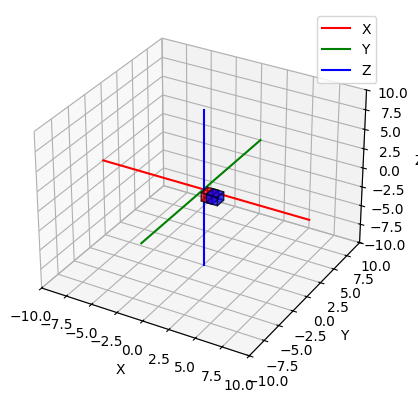

In [214]:
reflected_vertices_plane = reflect_cube_plane(scaled_vertices, "YZ")

plot_cubes(scaled_vertices, reflected_vertices_plane)

### Rotated

In [156]:
def generate_random_line():
    point = np.random.uniform(-5, 5, size=3)
    direction = np.random.uniform(-1, 1, size=3)
    direction /= np.linalg.norm(direction)
    return point, direction

In [157]:
def rotated_line_cube(cube_vertices, phi, point, direction):
    point = np.array(point, dtype=float)
    direction = np.array(direction, dtype=float)
    phi = float(phi)

    vertices_h = np.hstack((cube_vertices, np.ones((cube_vertices.shape[0], 1)))).T

    T = np.eye(4)
    T[:3, 3] = -point

    d_yz = np.sqrt(direction[1] ** 2 + direction[2] ** 2)
    cos_psi = direction[2] / d_yz
    sin_psi = direction[1] / d_yz

    R_x = np.array([
        [1, 0,        0,       0],
        [0, cos_psi, -sin_psi, 0],
        [0, sin_psi,  cos_psi, 0],
        [0, 0,        0,       1]
    ])

    d_xyz = np.sqrt(direction[0] ** 2 + direction[1] ** 2 + direction[2] ** 2)

    cos_theta = d_yz / d_xyz
    sin_theta = direction[0] / d_xyz

    R_y = np.array([
        [ cos_theta, 0, sin_theta, 0],
        [ 0,         1, 0,         0],
        [-sin_theta, 0, cos_theta, 0],
        [ 0,         0, 0,         1]
    ])

    R_z = np.array([
        [np.cos(phi), -np.sin(phi), 0, 0],
        [np.sin(phi),  np.cos(phi), 0, 0],
        [0,            0,           1, 0],
        [0,            0,           0, 1]
    ])

    T_inv = np.linalg.inv(T)
    R_x_inv = np.linalg.inv(R_x)
    R_y_inv = np.linalg.inv(R_y)

    M = T_inv @ R_x_inv @ R_y_inv @ R_z @ R_y @ R_x @ T

    rotated = (M @ vertices_h).T[:, :3]

    return rotated


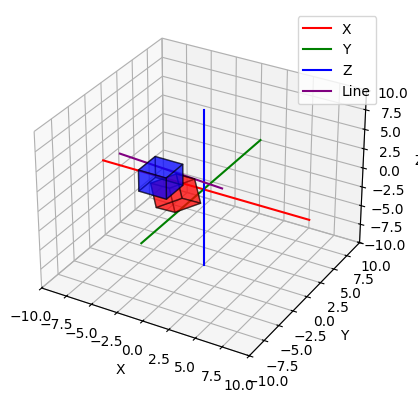

In [184]:
point, direction = generate_random_line()
rotated_cube = rotated_line_cube(cube_vertices, 45, point, direction)
plot_cubes(cube_vertices, rotated_cube, line_data=(point, direction))

### Plane

In [159]:
def generate_random_plane():
    point = np.random.uniform(-5, 5, size=3)
    normal = np.random.uniform(-1, 1, size=3)
    return point, normal

In [212]:
def reflected_plane_cube(cube_vertices, plane_point, plane_normal):
    plane_point = np.array(plane_point, dtype=float)
    plane_normal = np.array(plane_normal, dtype=float)

    vertices_h = np.hstack((cube_vertices, np.ones((cube_vertices.shape[0], 1)))).T

    T = np.eye(4)
    T[:3, 3] = -plane_point

    A = plane_normal[0]
    B = plane_normal[1]
    C = plane_normal[2]
    D =-plane_point[0]*A - plane_point[1]*B - plane_point[2]*C

    M1 = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0],
                   [0, 0, 1, D/C],
                   [0, 0, 0, 1]])

    M2 = np.array([[A/np.sqrt(A*A + B*B), B/np.sqrt(A*A + B*B), 0, 0],
                   [-B/np.sqrt(A*A + B*B), A/np.sqrt(A*A + B*B), 0, 0],
                   [0, 0, 1, 0],
                   [0, 0, 0, 1]])

    M3 = np.array([[C/np.sqrt(A*A + B*B + C*C), 0, -np.sqrt(A*A + B*B)/np.sqrt(A*A + B*B + C*C), 0],
                   [0, 1, 0, 0],
                   [np.sqrt(A*A + B*B)/np.sqrt(A*A + B*B + C*C), 0, C/np.sqrt(A*A + B*B + C*C), 0],
                   [0, 0, 0, 1]])

    M4 = np.array([[1, 0, 0, 0],
                   [0, 1, 0, 0],
                   [0, 0, -1, 0],
                   [0, 0, 0, 1]])

    M5 = np.linalg.inv(M3)
    M6 = np.linalg.inv(M2)
    M7 = np.linalg.inv(M1)

    M = M7 @ M6 @ M5 @ M4 @ M3 @ M2 @ M1

    reflected = (M @ vertices_h).T[:, :3]

    return reflected


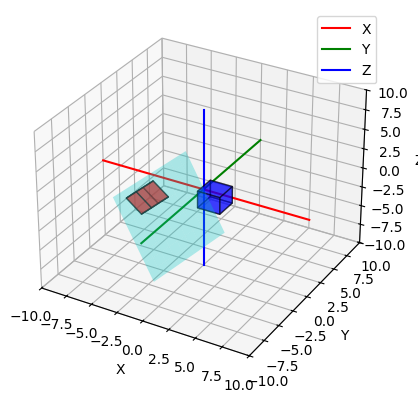

In [213]:
plane_point, plane_normal = generate_random_plane()
reflected_cube = reflected_plane_cube(cube_vertices, plane_point, plane_normal)

plot_cubes(cube_vertices, reflected_cube, plane_data=(plane_point, plane_normal))

### Projection

In [162]:
def project_points(cube_vertices, plane_normal):
    n = plane_normal / np.linalg.norm(plane_normal)
    I = np.eye(3)
    n_outer = np.outer(n, n)
    P = I - n_outer
    return np.dot(cube_vertices, P.T)

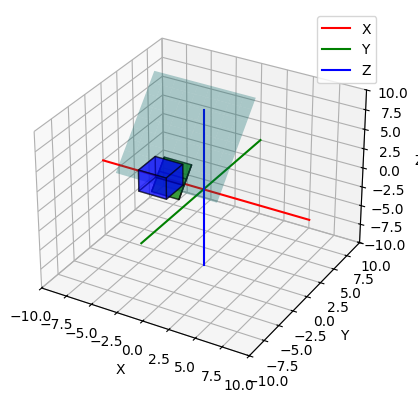

In [183]:
projected = project_points(cube_vertices, plane_normal)

plot_cubes(cube_vertices, plane_data=(plane_point, plane_normal), projected_vertices=projected)